# 🚀 Batalha de Feature Engineering: Cenário Multivariado
**Manual FE vs Automated FE (`tsfresh`) em Alta Dimensionalidade**

Nesta Fase 2, aumentamos a complexidade. Usaremos o dataset **Beijing PM2.5 Air Quality**, preveendo o nível de poluição diário com base não apenas no histórico da própria poluição, mas também de variáveis exógenas como Temperatura, Ponto de Orvalho, Pressão e Vento.

Compararemos a performance e o custo de:
1. **Manual FE**: Lags e médias de múltiplas variáveis criadas manualmente.
2. **Auto FE**: Extrator de janelas do `tsfresh` sobre múltiplas variáveis.

Modelos na disputa: LightGBM, XGBoost, CatBoost, Random Forest e Ridge Regression.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import roll_time_series, impute
from tsfresh.feature_extraction import EfficientFCParameters

plt.style.use('dark_background')



## 1. Carregamento e Agregação do Dataset (Beijing PM2.5)
Agregaremos os dados de hora em hora para **frequência diária**, facilitando o treinamento rápido e extraindo a tendência climática estrutural.


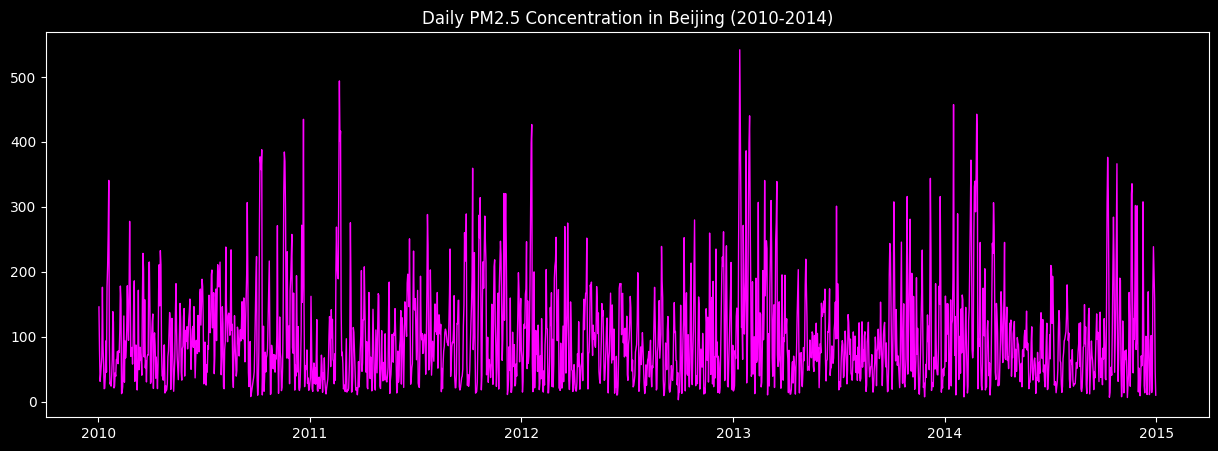

Total de dias: 1825


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv"
df_raw = pd.read_csv(url)

# Criar coluna datetime
df_raw['date'] = pd.to_datetime(df_raw[['year', 'month', 'day', 'hour']])

# Selecionar variáveis contínuas alvo
cols_of_interest = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']
df_raw = df_raw[['date'] + cols_of_interest].copy()

# Preencher NaNs interpolando
df_raw['pm2.5'] = df_raw['pm2.5'].interpolate(method='linear')
df_raw = df_raw.dropna()

# Agregar para dados DIÁRIOS (média de cada dia)
df_daily = df_raw.set_index('date').resample('D').mean().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(df_daily['date'], df_daily['pm2.5'], color='magenta', linewidth=1)
plt.title('Daily PM2.5 Concentration in Beijing (2010-2014)')
plt.show()

print(f"Total de dias: {len(df_daily)}")



## 2. Feature Engineering Manual Multivariada 🧠
Vamos criar lags (1, 2, 3, 7) e médias móveis (7 dias) para **cada uma das 5 variáveis**.


In [3]:
df_manual = df_daily.copy()
start_time = time.time()

# Target será o pm2.5 no dia seguinte
df_manual['target'] = df_manual['pm2.5'].shift(-1)

features_cols = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']
lags = [1, 2, 3, 7]

# Lags para TODAS as variáveis
for col in features_cols:
    for lag in lags:
        df_manual[f'{col}_lag_{lag}'] = df_manual[col].shift(lag-1) # lag-1 porque a linha atual já é o lag 1 pro target shifted

# Médias móveis
for col in features_cols:
    df_manual[f'{col}_rolling_mean_7'] = df_manual[col].rolling(window=7).mean()

# Features temporais
df_manual['month'] = df_manual['date'].dt.month
df_manual['day_of_week'] = df_manual['date'].dt.dayofweek

df_manual = df_manual.dropna().reset_index(drop=True)
manual_fe_time = time.time() - start_time

print(f"Manual FE concluída em {manual_fe_time:.2f} segundos.")
print(f"Total features manuais: {df_manual.shape[1] - 3}") # exclui date, pm2.5 atual e target



Manual FE concluída em 0.01 segundos.
Total features manuais: 31


## 3. Feature Engineering Automática Multivariada (`tsfresh`) 🤖
Enviaremos as 5 variáveis para o `tsfresh` gerar cruzamentos automáticos em janelas de até 7 dias.


In [4]:
start_time = time.time()

df_tsfresh = df_daily.copy()
df_tsfresh['id'] = 1

# O Target continua sendo o pm2.5 do dia seguinte
target = df_daily.set_index('date')['pm2.5'].shift(-1)

# Roll
df_rolled = roll_time_series(df_tsfresh, column_id="id", column_sort="date", max_timeshift=6, min_timeshift=6)
print(f"Rolled Data Shape: {df_rolled.shape}")

# Extract (isso vai extrair features de TODAS as 5 colunas de uma vez)
X_auto = extract_features(df_rolled, column_id="id", column_sort="date",
                          default_fc_parameters=EfficientFCParameters(),
                          impute_function=impute, n_jobs=4)

X_auto = X_auto.reset_index(level=0, drop=True).sort_index()

# Juntar target
df_auto_full = X_auto.join(target.rename('target'), how='inner').dropna(subset=['target'])
y_auto = df_auto_full['target']
X_auto = df_auto_full.drop(columns=['target'])

# Remover caracteres especiais das colunas (para LightGBM/XGBoost)
X_auto.columns = [re.sub(r'[",\[\]{}:]', '', str(col)) for col in X_auto.columns]

# Selecionar as melhores features
X_auto_selected = select_features(X_auto, y_auto)

auto_fe_time = time.time() - start_time
print(f"Auto FE concluída em {auto_fe_time:.2f} segundos.")
print(f"Features originais: {X_auto.shape[1]} | Selecionadas: {X_auto_selected.shape[1]}")



Rolling:   0%|          | 0/80 [00:00<?, ?it/s]

Rolling:   1%|▏         | 1/80 [00:01<02:00,  1.53s/it]

Rolling:  16%|█▋        | 13/80 [00:01<00:06, 10.87it/s]

Rolling:  35%|███▌      | 28/80 [00:01<00:01, 26.01it/s]

Rolling:  52%|█████▎    | 42/80 [00:01<00:00, 41.29it/s]

...

Feature Extraction:  85%|████████▌ | 17/20 [00:41<00:08,  2.67s/it]

Feature Extraction:  90%|█████████ | 18/20 [00:42<00:04,  2.30s/it]

Feature Extraction:  95%|█████████▌| 19/20 [00:44<00:01,  1.99s/it]

Feature Extraction: 100%|██████████| 20/20 [00:44<00:00,  2.21s/it]

Auto FE concluída em 57.49 segundos.
Features originais: 3885 | Selecionadas: 313


## 4. O Grande Duelo de Modelos ⚔️


In [5]:
# Split Manual
test_size = 365
train_m = df_manual.iloc[:-test_size]
test_m = df_manual.iloc[-test_size:]

cols_to_drop = ['date', 'target'] + features_cols # remove as originais puras também (t) pra ser justo
X_train_m = train_m.drop(columns=cols_to_drop, errors='ignore')
y_train_m = train_m['target']
X_test_m = test_m.drop(columns=cols_to_drop, errors='ignore')
y_test_m = test_m['target']

# Split Auto (alinhar índices para garantir teste no mesmo período)
train_a = X_auto_selected.iloc[:-test_size]
y_train_a = y_auto.iloc[:-test_size]
test_a = X_auto_selected.iloc[-test_size:]
y_test_a = y_auto.iloc[-test_size:]

results = []

def train_and_eval(ModelClass, name, X_tr, y_tr, X_te, y_te, fe_type, fe_time, **kwargs):
    start = time.time()
    model = ModelClass(**kwargs)
    model.fit(X_tr, y_tr)
    t_time = time.time() - start
    
    preds = model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    
    results.append({
        'Model': name,
        'FE': fe_type,
        'N_Features': X_tr.shape[1],
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'FE_Time(s)': fe_time,
        'Train_Time(s)': t_time
    })
    print(f"[{fe_type}] {name} | MAE: {mae:.4f} | Tempo Treino: {t_time:.2f}s")

# Modelos
models = [
    (Ridge, 'Ridge Regression', {'random_state':42}),
    (RandomForestRegressor, 'Random Forest', {'random_state':42, 'n_estimators':100, 'n_jobs':-1}),
    (LGBMRegressor, 'LightGBM', {'random_state':42, 'n_estimators':100, 'verbose':-1}),
    (XGBRegressor, 'XGBoost', {'random_state':42, 'n_estimators':100}),
    (CatBoostRegressor, 'CatBoost', {'random_state':42, 'n_estimators':100, 'verbose':0, 'allow_writing_files':False})
]

print("--- Treinando com Features MANUAIS ---")
for ModelClass, name, kwargs in models:
    train_and_eval(ModelClass, name, X_train_m, y_train_m, X_test_m, y_test_m, 'Manual', manual_fe_time, **kwargs)

print("\n--- Treinando com Features AUTOMÁTICAS (tsfresh) ---")
for ModelClass, name, kwargs in models:
    train_and_eval(ModelClass, name, train_a, y_train_a, test_a, y_test_a, 'Automated (tsfresh)', auto_fe_time, **kwargs)



--- Treinando com Features MANUAIS ---
[Manual] Ridge Regression | MAE: 46.7838 | Tempo Treino: 0.01s


[Manual] Random Forest | MAE: 46.0732 | Tempo Treino: 0.62s
[Manual] LightGBM | MAE: 47.0929 | Tempo Treino: 0.17s


[Manual] XGBoost | MAE: 49.3226 | Tempo Treino: 0.22s


[Manual] CatBoost | MAE: 50.1762 | Tempo Treino: 0.37s

--- Treinando com Features AUTOMÁTICAS (tsfresh) ---
[Automated (tsfresh)] Ridge Regression | MAE: 51.0859 | Tempo Treino: 0.01s


[Automated (tsfresh)] Random Forest | MAE: 48.6107 | Tempo Treino: 4.79s


[Automated (tsfresh)] LightGBM | MAE: 50.0799 | Tempo Treino: 0.41s


[Automated (tsfresh)] XGBoost | MAE: 52.0630 | Tempo Treino: 0.82s


[Automated (tsfresh)] CatBoost | MAE: 51.3044 | Tempo Treino: 0.88s


,Model,FE,N_Features,MAE,RMSE,R2,FE_Time(s),Train_Time(s)
6,Random Forest,Automated (tsfresh),313,48.610672,66.050752,0.341027,57.485588,4.788692
7,LightGBM,Automated (tsfresh),313,50.079931,67.106572,0.319792,57.485588,0.413068
5,Ridge Regression,Automated (tsfresh),313,51.085866,67.150913,0.318892,57.485588,0.010511
9,CatBoost,Automated (tsfresh),313,51.304434,67.937916,0.302834,57.485588,0.880303
8,XGBoost,Automated (tsfresh),313,52.062997,68.678131,0.287559,57.485588,0.818282
1,Random Forest,Manual,27,46.073170,62.730975,0.405604,0.006010,0.623841
0,Ridge Regression,Manual,27,46.783789,63.932657,0.382613,0.006010,0.007004
2,LightGBM,Manual,27,47.092929,64.005079,0.381214,0.006010,0.173543
3,XGBoost,Manual,27,49.322621,66.330532,0.335433,0.006010,0.217543
4,CatBoost,Manual,27,50.176151,65.941605,0.343203,0.006010,0.365667


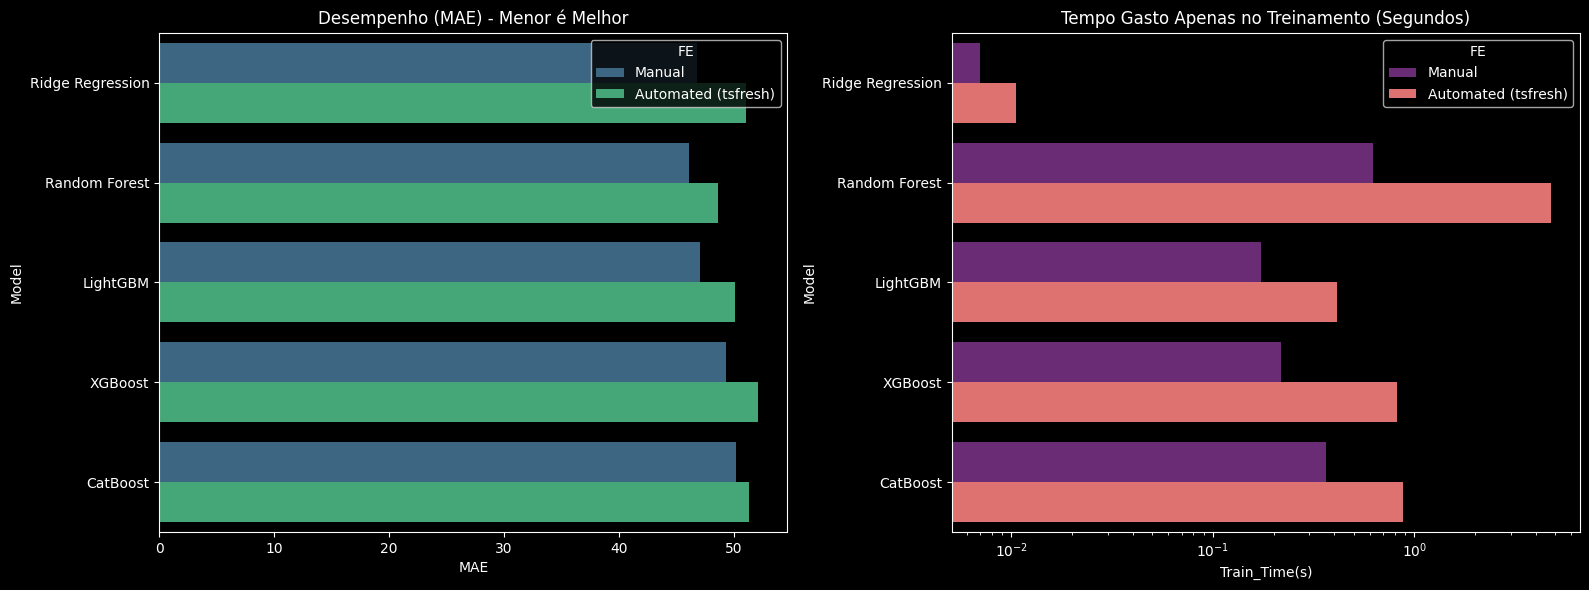

In [6]:
res_df = pd.DataFrame(results)
display(res_df.sort_values(['FE', 'MAE']))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=res_df, x='MAE', y='Model', hue='FE', ax=axes[0], palette='viridis')
axes[0].set_title('Desempenho (MAE) - Menor é Melhor')

sns.barplot(data=res_df, x='Train_Time(s)', y='Model', hue='FE', ax=axes[1], palette='magma')
axes[1].set_title('Tempo Gasto Apenas no Treinamento (Segundos)')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

